# Clustering Method Comparison — Mean-Pooled Embeddings

Runs all four clustering methods from `cluster_alts.py` on the pre-computed
`mean_pooled_embeddings.pkl` file and visualizes each result with t-SNE.

Clustering Algorithms Used:
1. Fuzzy K-Means
2. Spectral Clustering
3. DBSCAN
4. GMM

### Step 1: Setup (drive mounting, paths)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE           = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/calced_embeddings"
PROJECT_BASE         = "/content/drive/MyDrive/S2026/CS 274/Playlist-Recommender"
EMBEDDINGS_PKL       = f"{DRIVE_BASE}/mean_pooled_embeddings.pkl"
CLUSTERS_OUTPUT_DIR  = f"{PROJECT_BASE}/new clusters"
REPO_DIR             = "/content/RecsysUpgrade"

import os
os.makedirs(CLUSTERS_OUTPUT_DIR, exist_ok=True)
print("Paths configured.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


### Step 2: Clone repo, install requirements.txt and import `cluster_alts`

In [2]:
import os

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/siddmohanty111/RecsysUpgrade.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

print("Repo ready:", REPO_DIR)

Already up to date.
Repo ready: /content/RecsysUpgrade


In [3]:
%pip install -r {REPO_DIR}/requirements.txt

In [4]:
import os

cluster_alts_path = os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "cluster_alts.py")

with open(cluster_alts_path, 'r') as f:
    content = f.read()

# Replace the incorrect import statement
content = content.replace('from skfuzzy import cmeans, cmeans_predict', 'import skfuzzy as fuzz')

# Replace function calls
content = content.replace('cmeans(', 'fuzz.cmeans(')
content = content.replace('cmeans_predict(', 'fuzz.cmeans_predict(')

with open(cluster_alts_path, 'w') as f:
    f.write(content)

print(f"Successfully modified {cluster_alts_path} to correct skfuzzy imports.")

Successfully modified /content/RecsysUpgrade/PlaylistRecsysUpgrade/clustering/cluster_alts.py to correct skfuzzy imports.


In [5]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "cluster_alts",
    os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "cluster_alts.py"),
)
cluster_alts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cluster_alts)

print("cluster_alts loaded.")

cluster_alts loaded.


#### cuML needs a special install

In [6]:
%pip install \
    --extra-index-url=https://pypi.nvidia.com \
    "cudf-cu13==26.4.*" "dask-cudf-cu13==26.4.*" "cuml-cu13==26.4.*" \
    "cugraph-cu13==26.4.*" "nx-cugraph-cu13==26.4.*" "cuxfilter-cu13==26.4.*" \
    "cucim-cu13==26.4.*" "pylibraft-cu13==26.4.*" "raft-dask-cu13==26.4.*" \
    "cuvs-cu13==26.4.*" "nx-cugraph-cu13==26.4.*"

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


### Step 3 — Load embeddings

In [7]:
import pickle
import numpy as np

with open(EMBEDDINGS_PKL, 'rb') as f:
    data = pickle.load(f)

# Support both a raw dict (pid -> vector) and the structured dict used by other pipeline scripts
if isinstance(data, dict) and 'playlist_embeddings' in data:
    playlist_embeddings = data['playlist_embeddings']
    playlist_titles     = data.get('playlist_titles', {})
    playlist_tracks     = data.get('playlist_tracks', {})
else:
    # Assume the file is directly a pid -> embedding dict
    playlist_embeddings = data
    playlist_titles     = {}
    playlist_tracks     = {}

embedding_matrix = np.array(list(playlist_embeddings.values()))
pids = list(playlist_embeddings.keys())

print(f"Loaded {len(pids)} playlists, embedding dim = {embedding_matrix.shape[1]}")

Loaded 1000001 playlists, embedding dim = 768


### Step 4: Configuration

In [10]:
import random
import numpy as np

NUM_CLUSTERS = [50, 100, 200]

CLUSTER_SAMPLE = min(50_000, len(pids))

print("Sampling data for faster clustering...")
random.seed(42)
sampled_pids = random.sample(pids, CLUSTER_SAMPLE)

sampled_playlist_embeddings = {pid: playlist_embeddings[pid] for pid in sampled_pids}
sampled_playlist_titles = {pid: playlist_titles.get(pid, "") for pid in sampled_pids}
sampled_playlist_tracks = {pid: playlist_tracks.get(pid, []) for pid in sampled_pids}

sampled_embedding_matrix = np.array([sampled_playlist_embeddings[pid] for pid in sampled_pids])

# t-SNE sample size — reduce if the full dataset is too large
TSNE_SAMPLE = min(5000, len(sampled_pids))

print(f"Clustering into {NUM_CLUSTERS[0]} clusters (using the first value from NUM_CLUSTERS list) on a sample of {CLUSTER_SAMPLE} playlists.\nt-SNE on {TSNE_SAMPLE} playlists.")

Sampling data for faster clustering...
Clustering into 50 clusters (using the first value from NUM_CLUSTERS list) on a sample of 50000 playlists.
t-SNE on 5000 playlists.


### Step 6: Gaussian Mixture Model

In [14]:
import pandas as pd
from sklearn.mixture import GaussianMixture

gaussianmix_output = os.path.join(CLUSTERS_OUTPUT_DIR, "gaussianmix_clusters.csv")

print("Fitting Gaussian Mixture Model...")
# Changed covariance_type to 'diag' for faster computation in high dimensions
gm = GaussianMixture(n_components=NUM_CLUSTERS[0], random_state=0, verbose=2, covariance_type='diag')

print("Starting GMM fit (verbose output should appear below if computation is long)...")
gm.fit(sampled_embedding_matrix)
print("GMM fit complete.")

gaussianmix_labels = gm.predict(sampled_embedding_matrix);

pd.DataFrame({
    'pid': sampled_pids,
    'cluster': gaussianmix_labels
}).to_csv(gaussianmix_output, index=False);

print(f"Gaussian Mixture done. Results saved to {gaussianmix_output}")

Fitting Gaussian Mixture Model...
Starting GMM fit (verbose output should appear below if computation is long)...
Initialization 0


KeyboardInterrupt: 

### Step 7: Fuzzy K-Means

In [16]:
import pandas as pd
from skfuzzy import cmeans

fkmeans_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_clusters.csv")

print("Fitting Fuzzy K-Means...")
fkm_result = cmeans(embedding_matrix.T, NUM_CLUSTERS[0], 2, error=0.005, maxiter=1000)
fkmeans_labels = np.argmax(fkm_result[1], axis=0)

pd.DataFrame({
    'pid': pids,
    'cluster': fkmeans_labels
}).to_csv(fkmeans_output, index=False)

print(f"Fuzzy K-Means done. Results saved to {fkmeans_output}")

Fitting Fuzzy K-Means...
Fuzzy K-Means done. Results saved to /content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/calced_embeddings/new clusters/fkmeans_clusters.csv


### Step 8: t-SNE

In [21]:
from sklearn.manifold import TSNE
import numpy as np

# To keep complexity low for visualization, we will run t-SNE on a sample.
# The clustering (e.g., Fuzzy K-Means) is still performed on the full dataset.

# Use the sampled_embedding_matrix for t-SNE visualization
# sample_idx should be generated here to correspond to the points actually used for t-SNE
rng = np.random.default_rng(42)
sample_idx_tsne = rng.choice(len(pids), size=20000, replace=False)
tsne_input_matrix = embedding_matrix[sample_idx_tsne]
tsne_data_size = 20000

print(f"Running t-SNE on {tsne_data_size} sampled playlists...")
# n_jobs=-1 uses all available CPU cores
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
tsne_coords = tsne.fit_transform(tsne_input_matrix)
print("t-SNE complete.")

# The sample_idx for plotting should now reference the original position of the sampled data
# This means we need the labels corresponding to the sampled PIDs used for t-SNE
# For fkmeans, we ran it on the full data, so we need to map those full labels to our t-SNE sample.
# However, it's simpler to just ensure fkmeans_labels are consistent with sampled_pids,
# or re-run fkmeans on sampled_embedding_matrix if we want a 1:1 visualization of sampled clusters.
# For now, let's keep fkmeans_labels from the full dataset and pick the relevant ones for the t-SNE sample.


Running t-SNE on 20000 sampled playlists...
t-SNE complete.


### Step 9: Visualization

/tmp/ipykernel_24716/1185268950.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(len(unique_labels), 1))


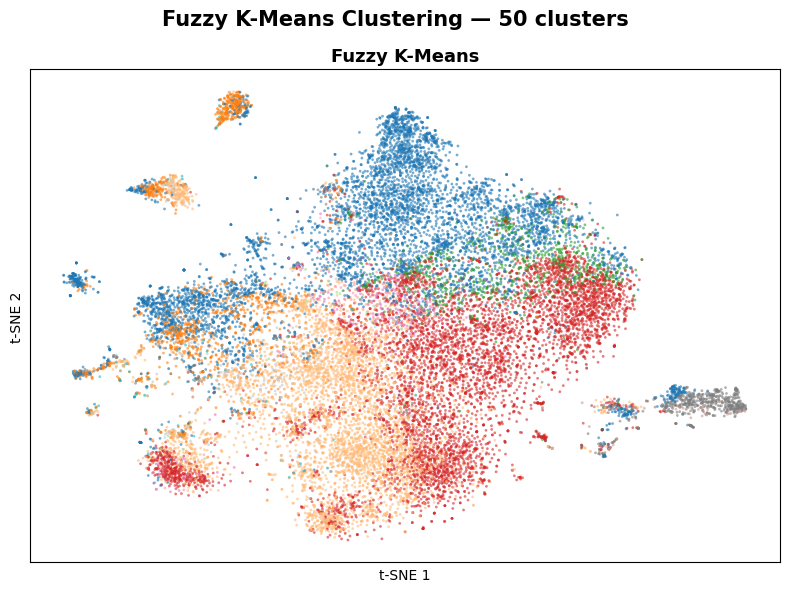

Plot saved.


In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get the pids that correspond to the t-SNE sample
sampled_pids_for_tsne = [pids[i] for i in sample_idx_tsne]

# Map the full fkmeans_labels back to these sampled pids
# We assume fkmeans_labels are indexed by the original `pids` list for the full dataset
# We need to map `sampled_pids_for_tsne` back to their indices in the original `pids` list
pid_to_full_label_idx = {pid: i for i, pid in enumerate(pids)}
fkmeans_labels_for_tsne_sample = np.array([fkmeans_labels[pid_to_full_label_idx[pid]] for pid in sampled_pids_for_tsne])

methods = {
    "Fuzzy K-Means": fkmeans_labels_for_tsne_sample,
}

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Extract the single method and its labels
title, labels = list(methods.items())[0]

unique_labels = np.unique(labels)
# Use a discrete colormap; noise points (-1 from DBSCAN) are grey
cmap = cm.get_cmap('tab20', max(len(unique_labels), 1))
colors = np.array([cmap(np.where(unique_labels == l)[0][0]) if l != -1 else (0.7, 0.7, 0.7, 1.0)
                   for l in labels])
ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
           c=colors, s=4, alpha=0.6, linewidths=0)
ax.set_title(title, fontsize=13, fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])

fig.suptitle(f"{title} Clustering — {NUM_CLUSTERS[0]} clusters",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CLUSTERS_OUTPUT_DIR, "clustering_comparison_tsne.png"), dpi=150)
plt.show()
print("Plot saved.")

### Spectral
Slow due to affinity matrix

In [ ]:
import pandas as pd
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
import matplotlib.cm as cm

spectral_output = os.path.join(CLUSTERS_OUTPUT_DIR, "spectral_clusters.csv")

print("Fitting Spectral Clustering...")
spectral_labels = SpectralClustering(
    n_clusters=NUM_CLUSTERS[0], affinity='nearest_neighbors', random_state=0, n_jobs=-1
).fit_predict(sampled_embedding_matrix)

pd.DataFrame({
    'pid': sampled_pids,
    'cluster': spectral_labels
}).to_csv(spectral_output, index=False)

print(f"Spectral Clustering done. Results saved to {spectral_output}")

# Visualize spectral result on the existing t-SNE projection
fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = np.unique(spectral_labels)
cmap = cm.get_cmap('tab20', len(unique_labels))
colors = np.array([cmap(np.where(unique_labels == l)[0][0]) for l in spectral_labels[sample_idx]])
ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=colors, s=4, alpha=0.6, linewidths=0)
ax.set_title("Spectral Clustering", fontsize=13, fontweight='bold')
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(os.path.join(CLUSTERS_OUTPUT_DIR, "spectral_tsne.png"), dpi=150)
plt.show()
print("Spectral plot saved.")

### Step 5: DBSCAN

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN

DBSCAN_EPS         = 0.5
DBSCAN_MIN_SAMPLES = 5

dbscan_output = os.path.join(CLUSTERS_OUTPUT_DIR, "dbscan_clusters.csv")

print("Fitting DBSCAN...")
dbscan_labels = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1).fit_predict(sampled_embedding_matrix)

pd.DataFrame({
    'pid': sampled_pids,
    'cluster': dbscan_labels
}).to_csv(dbscan_output, index=False)

n_found = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN done: {n_found} clusters, {n_noise} noise points. Results saved to {dbscan_output}")